# 新部署接口远程回归测试

本 Notebook 用于对新部署接口进行功能回归、异常处理验证与稳定性测试。

测试目标：
- 服务可用性（`/health`、可选`/version`）
- 核心推理冒烟（默认提示词）
- 多 Prompt 多图片行为
- 响应结构合法性
- 异常请求协议一致性
- 多轮稳定性与重试表现
- 可选新旧接口一致性对比
- 测试结果落盘（JSON/CSV）

## 1. 创建新测试 Notebook 与全局配置

In [1]:
# 全局配置
SERVICE_URL = "http://202.117.77.4:9208"
OLD_SERVICE_URL = None  # 可选：如需新旧接口对比，填入旧地址
API_KEY = None
TIMEOUT = 120

# 新接口优先：/v1/drone_detect
NEW_ENDPOINT = "/v1/drone_detect"
SMOKE_ENDPOINT = "/v1/detect"  # 大纲要求的最小可复现接口

TEST_IMAGES = {
    "vehicle": "images/vehicle_test.jpg",
    "person": "images/person_test.jpg",
}

ENABLE_AB_COMPARE = OLD_SERVICE_URL is not None

HEADERS = {"X-API-Key": API_KEY} if API_KEY else {}

print("✅ 全局配置完成")
print("SERVICE_URL:", SERVICE_URL)
print("ENABLE_AB_COMPARE:", ENABLE_AB_COMPARE)

✅ 全局配置完成
SERVICE_URL: http://202.117.77.4:9208
ENABLE_AB_COMPARE: False


## 2. 导入依赖与通用工具函数（Base64、请求封装、结果展示）

In [ ]:
import base64
import json
import time
import statistics
import csv
from pathlib import Path
from collections import Counter

import requests

OUTPUT_DIR = Path("test_outputs") / "remote_service_retest"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS = {
    "health": {},
    "smoke": {},
    "custom_prompt": [],
    "schema_validation": {},
    "exceptions": {},
    "stability": {},
    "ab_compare": {},
}


def img_to_b64(path: str | Path) -> str:
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"图片不存在: {p.resolve()}")
    return base64.b64encode(p.read_bytes()).decode("utf-8")


def post_json(base_url: str, endpoint: str, payload: dict, timeout: int = TIMEOUT, headers: dict | None = None):
    url = f"{base_url}{endpoint}"
    t0 = time.time()
    try:
        r = requests.post(url, json=payload, timeout=timeout, headers=headers or {})
        elapsed = time.time() - t0
        parsed = None
        try:
            parsed = r.json()
        except Exception:
            parsed = None
        return {
            "ok": r.status_code == 200,
            "status_code": r.status_code,
            "elapsed_s": elapsed,
            "json": parsed,
            "text_preview": (r.text or "")[:300],
            "error": None,
            "url": url,
        }
    except requests.RequestException as e:
        elapsed = time.time() - t0
        return {
            "ok": False,
            "status_code": None,
            "elapsed_s": elapsed,
            "json": None,
            "text_preview": None,
            "error": f"{type(e).__name__}: {e}",
            "url": url,
        }


def save_rendered_if_present(resp_json: dict | None, out_path: str | Path):
    if not isinstance(resp_json, dict):
        return False
    b64 = resp_json.get("image_base64")
    if not b64:
        return False
    Path(out_path).write_bytes(base64.b64decode(b64))
    return True


print("✅ 依赖与工具函数加载完成")
print("测试产物目录:", OUTPUT_DIR.resolve())

✅ 依赖与工具函数加载完成


## 3. 新接口健康检查与版本信息校验

In [3]:
health_url = f"{SERVICE_URL}/health"
version_url = f"{SERVICE_URL}/version"

health = {"status_code": None, "json": None, "error": None}
version = {"status_code": None, "json": None, "error": None}

try:
    r = requests.get(health_url, timeout=10)
    health["status_code"] = r.status_code
    health["json"] = r.json()
except Exception as e:
    health["error"] = f"{type(e).__name__}: {e}"

try:
    r = requests.get(version_url, timeout=10)
    version["status_code"] = r.status_code
    try:
        version["json"] = r.json()
    except Exception:
        version["json"] = {"raw": r.text[:200]}
except Exception as e:
    version["error"] = f"{type(e).__name__}: {e}"

RESULTS["health"] = {"health": health, "version": version}

print("/health =>", health)
print("/version =>", version)

assert health["status_code"] == 200, f"健康检查失败: {health}"
print("✅ 健康检查通过")

/health => {'status_code': 200, 'json': {'status': 'ok'}, 'error': None}
/version => {'status_code': 404, 'json': {'detail': 'Not Found'}, 'error': None}
✅ 健康检查通过


## 4. 核心推理接口冒烟测试（单图 + 默认提示词）

In [ ]:
smoke_img = TEST_IMAGES["vehicle"]
smoke_payload = {
    "image_base64": img_to_b64(smoke_img)
}

smoke_new = post_json(SERVICE_URL, NEW_ENDPOINT, smoke_payload, timeout=TIMEOUT, headers=HEADERS)
smoke_detect = post_json(SERVICE_URL, SMOKE_ENDPOINT, smoke_payload, timeout=TIMEOUT, headers=HEADERS)

# 优先记录新接口结果
RESULTS["smoke"] = {
    "new_endpoint": smoke_new,
    "detect_endpoint": smoke_detect,
}

Path(OUTPUT_DIR / "retest_smoke_new.json").write_text(
    json.dumps(smoke_new.get("json"), ensure_ascii=False, indent=2),
    encoding="utf-8",
)
Path(OUTPUT_DIR / "retest_smoke_detect.json").write_text(
    json.dumps(smoke_detect.get("json"), ensure_ascii=False, indent=2),
    encoding="utf-8",
)

saved_new = save_rendered_if_present(smoke_new.get("json"), OUTPUT_DIR / "retest_smoke_new_rendered.jpg")
saved_detect = save_rendered_if_present(smoke_detect.get("json"), OUTPUT_DIR / "retest_smoke_detect_rendered.jpg")

print("新接口状态:", smoke_new["status_code"], "耗时:", round(smoke_new["elapsed_s"], 3), "s")
print("detect接口状态:", smoke_detect["status_code"], "耗时:", round(smoke_detect["elapsed_s"], 3), "s")
print("渲染图保存（new/detect）:", saved_new, saved_detect)

assert smoke_new["status_code"] in (200, 422, 502, 503, 504), "新接口返回异常状态码"
print("✅ 冒烟测试完成")

新接口状态: 502 耗时: 4.844 s
detect接口状态: 200 耗时: 2.082 s
渲染图保存（new/detect）: False True
✅ 冒烟测试完成


## 5. 自定义 Prompt 功能测试（人/车/安全帽等场景）

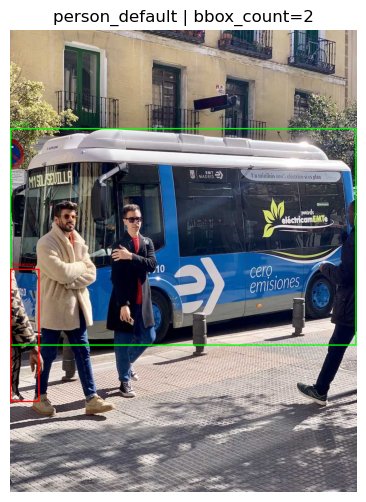


=== person_default ===
status: 200 elapsed_s: 0.569
api_top_fields: ['warning_results']
result_list_field: warning_results
result_item_fields: ['bbox_2d', 'description', 'warning_type']
labels: {'Vehicle': 1, 'NoHelmet': 1} obj_count: 2
bbox_drawn_count: 2 saved: retest_bbox_person_default.jpg
api_json:
{
  "warning_results": [
    {
      "warning_type": "Vehicle",
      "description": "检测到机动车目标，位于画面中间中部",
      "bbox_2d": [
        0,
        229,
        808,
        737
      ]
    },
    {
      "warning_type": "NoHelmet",
      "description": "检测到疑似未佩戴安全帽人员，位于画面中间左侧",
      "bbox_2d": [
        0,
        558,
        68,
        869
      ]
    }
  ]
}


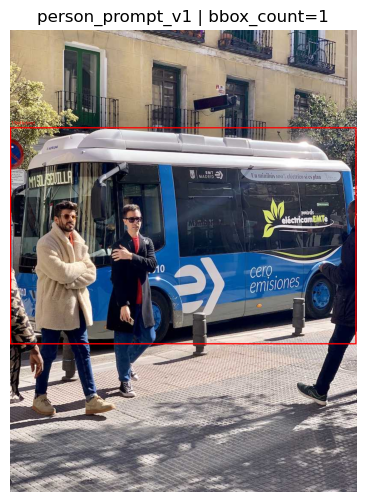


=== person_prompt_v1 ===
status: 200 elapsed_s: 0.5198
api_top_fields: ['warning_results']
result_list_field: warning_results
result_item_fields: ['bbox_2d', 'description', 'warning_type']
labels: {'NoHelmet': 1} obj_count: 1
bbox_drawn_count: 1 saved: retest_bbox_person_prompt_v1.jpg
api_json:
{
  "warning_results": [
    {
      "warning_type": "NoHelmet",
      "description": "检测到疑似未佩戴安全帽人员，位于画面中间中部",
      "bbox_2d": [
        0,
        227,
        808,
        734
      ]
    }
  ]
}


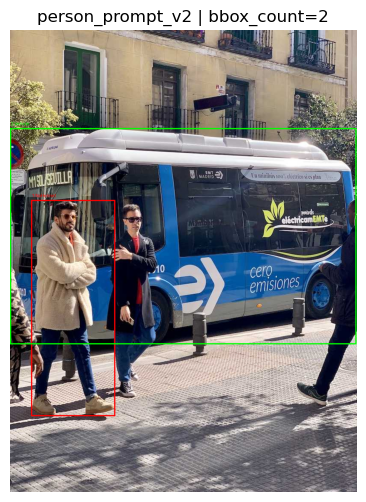


=== person_prompt_v2 ===
status: 200 elapsed_s: 0.8074
api_top_fields: ['warning_results']
result_list_field: warning_results
result_item_fields: ['bbox_2d', 'description', 'warning_type']
labels: {'NoHelmet': 1, 'Vehicle': 1} obj_count: 2
bbox_drawn_count: 2 saved: retest_bbox_person_prompt_v2.jpg
api_json:
{
  "warning_results": [
    {
      "warning_type": "NoHelmet",
      "description": "检测到疑似未佩戴安全帽人员，位于画面中间左侧",
      "bbox_2d": [
        49,
        397,
        245,
        902
      ]
    },
    {
      "warning_type": "Vehicle",
      "description": "检测到机动车目标，位于画面中间中部",
      "bbox_2d": [
        0,
        229,
        808,
        734
      ]
    }
  ]
}


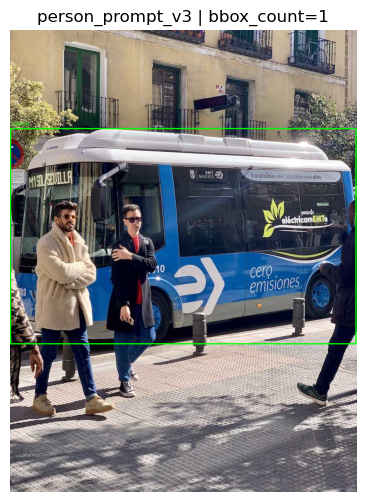


=== person_prompt_v3 ===
status: 200 elapsed_s: 0.7147
api_top_fields: ['warning_results']
result_list_field: warning_results
result_item_fields: ['bbox_2d', 'description', 'warning_type']
labels: {'Vehicle': 1} obj_count: 1
bbox_drawn_count: 1 saved: retest_bbox_person_prompt_v3.jpg
api_json:
{
  "warning_results": [
    {
      "warning_type": "Vehicle",
      "description": "检测到机动车目标，位于画面中间中部",
      "bbox_2d": [
        0,
        229,
        808,
        734
      ]
    }
  ]
}

✅ 自定义 Prompt 测试完成


In [ ]:
from PIL import Image as PILImage, ImageDraw
import matplotlib.pyplot as plt

PROMPT_V1 = """你是无人机图像告警检测模型。仅检测 NoHelmet 和 Vehicle 两类。
图像坐标：width=1280,height=720, 原点左上角，bbox_2d=[x1,y1,x2,y2]，坐标必须在范围内。
NoHelmet：仅当人员头部清晰可见且可确认未戴标准安全帽时输出；普通帽子/头巾/兜帽不算安全帽；头部遮挡、目标过小、模糊或无法确认时忽略。
Vehicle：仅当道路或路面中可清晰辨认为机动车（轿车/SUV/卡车/公交）时输出；非机动车、行人、阴影、反光、井盖、碎石等忽略；过小、严重遮挡或模糊时忽略。
输出要求：仅返回纯 JSON，格式为 {\"warning_results\":[{\"warning_type\":\"NoHelmet|Vehicle\",\"description\":\"中文简短依据+大致位置\",\"bbox_2d\":[x1,y1,x2,y2]}]}。
每个目标单独一条，多个同类目标不可合并；未命中则返回 {\"warning_results\":[]}；不要返回其他字段。"""

PROMPT_V2 = """只检测告警类型 NoHelmet 和 Vehicle。
规则：
1) NoHelmet：仅输出头部清晰可见且未佩戴标准安全帽的人员；无法确认则忽略。
2) Vehicle：仅输出可清晰识别的机动车；非机动车、行人、阴影和模糊小目标忽略。
3) bbox_2d 使用原图像素坐标 [x1,y1,x2,y2]，范围在 1280x720 内，单目标单框。
4) 仅输出纯 JSON：{\"warning_results\":[{\"warning_type\":...,\"description\":...,\"bbox_2d\":[...]}]}。
5) 无命中返回 {\"warning_results\":[]}，禁止输出额外字段。"""

PROMPT_V3 = """你只需给出高置信度告警结果。
仅允许 warning_type 为 NoHelmet 或 Vehicle；不确定、遮挡、模糊、过小目标一律忽略（宁可漏检）。
每个目标独立输出，不合并目标。
必须返回纯 JSON 且只能包含 warning_results 数组；数组元素仅包含 warning_type、description、bbox_2d。
bbox_2d 为 [x1,y1,x2,y2] 原图像素坐标，坐标在 1280x720 内，且 x1<x2,y1<y2。
无目标时返回 {\"warning_results\":[]}。"""

prompt_cases = [
    {
        "name": "person_default",
        "image": TEST_IMAGES["person"],
        "prompt": None,
    },
    {
        "name": "person_prompt_v1",
        "image": TEST_IMAGES["person"],
        "prompt": PROMPT_V1,
    },
    {
        "name": "person_prompt_v2",
        "image": TEST_IMAGES["person"],
        "prompt": PROMPT_V2,
    },
    {
        "name": "person_prompt_v3",
        "image": TEST_IMAGES["person"],
        "prompt": PROMPT_V3,
    },
]

def _extract_bbox_items(api_json: dict):
    if not isinstance(api_json, dict):
        return []
    if isinstance(api_json.get("warning_results"), list):
        out = []
        for it in api_json["warning_results"]:
            if not isinstance(it, dict):
                continue
            bbox = it.get("bbox_2d")
            if isinstance(bbox, list) and len(bbox) == 4:
                out.append({
                    "label": str(it.get("warning_type") or "Unknown"),
                    "bbox": bbox,
                })
        return out
    if isinstance(api_json.get("objects"), list):
        out = []
        for it in api_json["objects"]:
            if not isinstance(it, dict):
                continue
            bbox = it.get("bbox_2d") or it.get("bbox")
            if isinstance(bbox, list) and len(bbox) == 4:
                out.append({
                    "label": str(it.get("label") or "Unknown"),
                    "bbox": bbox,
                })
        return out
    return []

def draw_bbox_preview(image_path: str, api_json: dict, case_name: str):
    src = PILImage.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(src)
    items = _extract_bbox_items(api_json)
    for idx, it in enumerate(items, start=1):
        try:
            x1, y1, x2, y2 = [int(v) for v in it["bbox"]]
        except Exception:
            continue
        color = "red" if it["label"] == "NoHelmet" else "lime"
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
        draw.text((x1 + 2, max(0, y1 - 16)), f"{idx}:{it['label']}", fill=color)

    out_path = OUTPUT_DIR / f"retest_bbox_{case_name}.jpg"
    src.save(out_path, format="JPEG")

    plt.figure(figsize=(9, 6))
    plt.imshow(src)
    plt.title(f"{case_name} | bbox_count={len(items)}")
    plt.axis("off")
    plt.show()

    return str(out_path), len(items)

custom_rows = []
for case in prompt_cases:
    payload = {"image_base64": img_to_b64(case["image"])}
    if case["prompt"]:
        payload["prompt"] = case["prompt"]
    out = post_json(SERVICE_URL, NEW_ENDPOINT, payload, timeout=TIMEOUT, headers=HEADERS)

    api_json = out.get("json") if isinstance(out.get("json"), dict) else {}
    api_top_fields = sorted(list(api_json.keys())) if api_json else []
    result_list_field = "none"
    result_item_fields = []

    label_counter = Counter()
    obj_count = 0
    if isinstance(api_json, dict):
        warning_results = api_json.get("warning_results")
        objects = api_json.get("objects")
        if isinstance(warning_results, list):
            result_list_field = "warning_results"
            obj_count = len(warning_results)
            for it in warning_results:
                if isinstance(it, dict):
                    label_counter[str(it.get("warning_type"))] += 1
            if warning_results and isinstance(warning_results[0], dict):
                result_item_fields = sorted(list(warning_results[0].keys()))
        elif isinstance(objects, list):
            result_list_field = "objects"
            obj_count = len(objects)
            for it in objects:
                if isinstance(it, dict):
                    label_counter[str(it.get("label"))] += 1
            if objects and isinstance(objects[0], dict):
                result_item_fields = sorted(list(objects[0].keys()))

    bbox_image_path, bbox_drawn_count = draw_bbox_preview(case["image"], api_json, case["name"])

    row = {
        "case": case["name"],
        "endpoint": NEW_ENDPOINT,
        "status_code": out["status_code"],
        "elapsed_s": round(out["elapsed_s"], 4),
        "obj_count": obj_count,
        "labels": dict(label_counter),
        "error": out["error"],
        "api_top_fields": api_top_fields,
        "result_list_field": result_list_field,
        "result_item_fields": result_item_fields,
        "bbox_image_path": bbox_image_path,
        "bbox_drawn_count": bbox_drawn_count,
    }
    custom_rows.append(row)
    print(f"\n=== {case['name']} ===")
    print("status:", row["status_code"], "elapsed_s:", row["elapsed_s"])
    print("api_top_fields:", row["api_top_fields"] or "<none>")
    print("result_list_field:", row["result_list_field"])
    print("result_item_fields:", row["result_item_fields"] or "<none>")
    print("labels:", row["labels"], "obj_count:", row["obj_count"])
    print("bbox_drawn_count:", row["bbox_drawn_count"], "saved:", row["bbox_image_path"])
    if row["error"]:
        print("error:", row["error"])
    print("api_json:")
    if api_json:
        print(json.dumps(api_json, ensure_ascii=False, indent=2))
    else:
        print(out.get("text_preview") or "<empty>")

RESULTS["custom_prompt"] = custom_rows
print("\n✅ 自定义 Prompt 测试完成")

## 6. 响应结构校验（字段完整性、坐标合法性、类型约束）

In [13]:
from PIL import Image as PILImage


def _extract_items(resp_json: dict):
    if not isinstance(resp_json, dict):
        return []
    if isinstance(resp_json.get("warning_results"), list):
        return resp_json["warning_results"], "warning_results"
    if isinstance(resp_json.get("objects"), list):
        return resp_json["objects"], "objects"
    return [], "none"


def validate_item(item: dict, image_w: int, image_h: int, mode: str):
    if not isinstance(item, dict):
        return False, "item 不是对象"

    key = "warning_type" if mode == "warning_results" else "label"
    if not item.get(key):
        return False, f"缺少 {key}"

    bbox = item.get("bbox_2d")
    if not (isinstance(bbox, list) and len(bbox) == 4):
        return False, "bbox_2d 不是四元数组"

    try:
        x1, y1, x2, y2 = [int(v) for v in bbox]
    except Exception:
        return False, "bbox_2d 含非数字"

    if not (0 <= x1 < x2 <= image_w and 0 <= y1 < y2 <= image_h):
        return False, "bbox 越界或坐标顺序错误"

    return True, "ok"


checks = []
for row in custom_rows:
    image_path = next(x["image"] for x in prompt_cases if x["name"] == row["case"])
    w, h = PILImage.open(image_path).size

    payload = {"image_base64": img_to_b64(image_path)}
    prompt = next(x["prompt"] for x in prompt_cases if x["name"] == row["case"])
    if prompt:
        payload["prompt"] = prompt
    out = post_json(SERVICE_URL, NEW_ENDPOINT, payload, timeout=TIMEOUT, headers=HEADERS)

    items, mode = _extract_items(out.get("json"))
    valid = 0
    errors = []
    for it in items:
        ok, msg = validate_item(it, w, h, mode)
        if ok:
            valid += 1
        else:
            errors.append(msg)

    total = len(items)
    rate = (valid / total) if total else 1.0
    checks.append({
        "case": row["case"],
        "mode": mode,
        "total_items": total,
        "valid_items": valid,
        "valid_rate": round(rate, 4),
        "errors": errors[:5],
    })

RESULTS["schema_validation"] = {
    "rows": checks,
    "overall_valid_rate": round(sum(x["valid_items"] for x in checks) / max(sum(x["total_items"] for x in checks), 1), 4),
}

for c in checks:
    print(c)
print("✅ 结构校验完成")

{'case': 'vehicle_default', 'mode': 'none', 'total_items': 0, 'valid_items': 0, 'valid_rate': 1.0, 'errors': []}
{'case': 'vehicle_prompt_v1', 'mode': 'warning_results', 'total_items': 10, 'valid_items': 10, 'valid_rate': 1.0, 'errors': []}
{'case': 'vehicle_prompt_v2', 'mode': 'warning_results', 'total_items': 11, 'valid_items': 11, 'valid_rate': 1.0, 'errors': []}
{'case': 'person_prompt_v3', 'mode': 'warning_results', 'total_items': 1, 'valid_items': 1, 'valid_rate': 1.0, 'errors': []}
✅ 结构校验完成


## 7. 异常请求测试（空请求、非法 Base64、超时与网络异常）

In [8]:
exception_results = {}

# 1) 空请求
r1 = post_json(SERVICE_URL, NEW_ENDPOINT, {}, timeout=10, headers=HEADERS)
exception_results["empty_payload"] = r1

# 2) 非法 base64
r2 = post_json(SERVICE_URL, NEW_ENDPOINT, {"image_base64": "!!invalid!!"}, timeout=10, headers=HEADERS)
exception_results["invalid_base64"] = r2

# 3) 非图像字节
fake = base64.b64encode(b"not image bytes").decode("utf-8")
r3 = post_json(SERVICE_URL, NEW_ENDPOINT, {"image_base64": fake}, timeout=10, headers=HEADERS)
exception_results["non_image_bytes"] = r3

# 4) 超时测试（极短超时）
try:
    payload = {"image_base64": img_to_b64(TEST_IMAGES["vehicle"]) }
    t0 = time.time()
    _ = requests.post(f"{SERVICE_URL}{NEW_ENDPOINT}", json=payload, timeout=0.001, headers=HEADERS)
    exception_results["forced_timeout"] = {"ok": True, "note": "did not timeout"}
except requests.RequestException as e:
    exception_results["forced_timeout"] = {
        "ok": False,
        "error": f"{type(e).__name__}: {e}",
        "elapsed_s": round(time.time() - t0, 4),
    }

RESULTS["exceptions"] = exception_results
for k, v in exception_results.items():
    print(k, "=>", v.get("status_code"), v.get("error") or v.get("text_preview", "")[:120])

print("✅ 异常请求测试完成")

empty_payload => 422 {"detail":[{"type":"missing","loc":["body","image_base64"],"msg":"Field required","input":{}}]}
invalid_base64 => 422 {"detail":"image_base64 is not a valid base64 image payload."}
non_image_bytes => 422 {"detail":"image_base64 could not be decoded into an image."}
forced_timeout => None ReadTimeout: HTTPConnectionPool(host='127.0.0.1', port=7890): Read timed out. (read timeout=0.001)
✅ 异常请求测试完成


## 8. 多轮稳定性测试（重试、状态码分布、耗时统计）

In [14]:
N_ROUNDS = 8
MAX_RETRIES = 2
BACKOFF = 1.0
RETRY_STATUS = {502, 503, 504}

status_counter = Counter()
latencies = []
success = 0
fail = 0
retry_count = 0

payload = {
    "image_base64": img_to_b64(TEST_IMAGES["person"]),
    "prompt": PROMPT_V3,
}

for i in range(1, N_ROUNDS + 1):
    final_ok = False
    for a in range(MAX_RETRIES + 1):
        out = post_json(SERVICE_URL, NEW_ENDPOINT, payload, timeout=TIMEOUT, headers=HEADERS)
        latencies.append(out["elapsed_s"])
        sc = out["status_code"]
        status_counter[str(sc)] += 1

        if sc == 200 and isinstance(out.get("json"), dict):
            final_ok = True
            break

        if sc in RETRY_STATUS and a < MAX_RETRIES:
            retry_count += 1
            time.sleep(BACKOFF * (2 ** a))
        else:
            break

    if final_ok:
        success += 1
    else:
        fail += 1

stability = {
    "rounds": N_ROUNDS,
    "success": success,
    "failed": fail,
    "success_rate": round(success / N_ROUNDS, 4),
    "retry_count": retry_count,
    "status_distribution": dict(status_counter),
    "p50_latency_s": round(statistics.median(latencies), 4) if latencies else None,
    "p95_latency_s": round(sorted(latencies)[int(0.95 * (len(latencies) - 1))], 4) if latencies else None,
    "max_latency_s": round(max(latencies), 4) if latencies else None,
    "prompt_used": "PROMPT_V3",
}

RESULTS["stability"] = stability
print(json.dumps(stability, ensure_ascii=False, indent=2))
print("✅ 稳定性测试完成")

{
  "rounds": 8,
  "success": 8,
  "failed": 0,
  "success_rate": 1.0,
  "retry_count": 0,
  "status_distribution": {
    "200": 8
  },
  "p50_latency_s": 0.5629,
  "p95_latency_s": 0.5761,
  "max_latency_s": 0.5882,
  "prompt_used": "PROMPT_V3"
}
✅ 稳定性测试完成


## 9. 新旧接口一致性对比（可选：同图同 Prompt）

In [15]:
ab_result = {
    "enabled": ENABLE_AB_COMPARE,
    "rows": [],
}

if ENABLE_AB_COMPARE:
    case_img = TEST_IMAGES["person"]
    payload = {
        "image_base64": img_to_b64(case_img),
        "prompt": PROMPT_V3,
    }

    new_out = post_json(SERVICE_URL, NEW_ENDPOINT, payload, timeout=TIMEOUT, headers=HEADERS)
    old_out = post_json(OLD_SERVICE_URL, NEW_ENDPOINT, payload, timeout=TIMEOUT, headers=HEADERS)

    def _count_labels(obj):
        if not isinstance(obj, dict):
            return Counter()
        if isinstance(obj.get("warning_results"), list):
            return Counter(str(x.get("warning_type")) for x in obj["warning_results"] if isinstance(x, dict))
        if isinstance(obj.get("objects"), list):
            return Counter(str(x.get("label")) for x in obj["objects"] if isinstance(x, dict))
        return Counter()

    c_new = _count_labels(new_out.get("json"))
    c_old = _count_labels(old_out.get("json"))

    ab_result["rows"].append({
        "new_status": new_out["status_code"],
        "old_status": old_out["status_code"],
        "new_labels": dict(c_new),
        "old_labels": dict(c_old),
        "label_overlap": sorted(list(set(c_new.keys()) & set(c_old.keys()))),
        "prompt_used": "PROMPT_V3",
    })

RESULTS["ab_compare"] = ab_result
print(json.dumps(ab_result, ensure_ascii=False, indent=2))
print("✅ A/B 对比完成（未启用时仅输出 enabled=false）")

{
  "enabled": false,
  "rows": []
}
✅ A/B 对比完成（未启用时仅输出 enabled=false）


## 10. 测试结果汇总与报告落盘（JSON/CSV）

In [ ]:
summary = {
    "health_ok": RESULTS.get("health", {}).get("health", {}).get("status_code") == 200,
    "smoke_new_status": RESULTS.get("smoke", {}).get("new_endpoint", {}).get("status_code"),
    "smoke_detect_status": RESULTS.get("smoke", {}).get("detect_endpoint", {}).get("status_code"),
    "custom_cases": len(RESULTS.get("custom_prompt", [])),
    "schema_overall_valid_rate": RESULTS.get("schema_validation", {}).get("overall_valid_rate"),
    "stability_success_rate": RESULTS.get("stability", {}).get("success_rate"),
    "ab_enabled": RESULTS.get("ab_compare", {}).get("enabled"),
}

raw_path = OUTPUT_DIR / "retest_raw.json"
summary_path = OUTPUT_DIR / "retest_summary.json"
csv_path = OUTPUT_DIR / "retest_summary.csv"

raw_path.write_text(json.dumps(RESULTS, ensure_ascii=False, indent=2), encoding="utf-8")
summary_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")

csv_rows = []
for row in RESULTS.get("custom_prompt", []):
    csv_rows.append({
        "section": "custom_prompt",
        "case": row.get("case"),
        "status_code": row.get("status_code"),
        "elapsed_s": row.get("elapsed_s"),
        "obj_count": row.get("obj_count"),
        "error": row.get("error"),
    })

for row in RESULTS.get("schema_validation", {}).get("rows", []):
    csv_rows.append({
        "section": "schema_validation",
        "case": row.get("case"),
        "status_code": None,
        "elapsed_s": None,
        "obj_count": row.get("total_items"),
        "error": "; ".join(row.get("errors", [])) if row.get("errors") else "",
    })

with csv_path.open("w", newline="", encoding="utf-8-sig") as f:
    writer = csv.DictWriter(f, fieldnames=["section", "case", "status_code", "elapsed_s", "obj_count", "error"])
    writer.writeheader()
    writer.writerows(csv_rows)

print("===== 测试摘要 =====")
print(json.dumps(summary, ensure_ascii=False, indent=2))
print("已保存:", raw_path)
print("已保存:", summary_path)
print("已保存:", csv_path)

===== 测试摘要 =====
{
  "health_ok": true,
  "smoke_new_status": 502,
  "smoke_detect_status": 200,
  "custom_cases": 4,
  "schema_overall_valid_rate": 1.0,
  "stability_success_rate": 1.0,
  "ab_enabled": false
}
已保存: retest_raw.json
已保存: retest_summary.json
已保存: retest_summary.csv
